In [1]:
import torch
from torch.nn.functional import pad
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

In [2]:
from tqdm.notebook import tqdm

In [3]:
# need to add path using os and sys first
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
# and now we can import the model
from models.model import MainModel

In [4]:
from datasets import load_from_disk

In [5]:
import tokenmonster

In [6]:
tokenizer_file = "english-8000-balanced-v1"

In [7]:
vocab = tokenmonster.load_multiprocess_safe(tokenizer_file)

In [8]:
initial_vocab_size = len(vocab)

In [9]:
pad_idx = initial_vocab_size
mask_idx = initial_vocab_size + 1

In [10]:
vocab_size = initial_vocab_size + 2

In [11]:
question_len = 256
context_len = 512
answer_len = 100

In [12]:
embedding_dim = 512
num_heads = 8
target_len = answer_len
num_layers = 1
phm_factor = 8
lm_head_phm_factor = 2
batch_size = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [13]:
checkpoint_dir = "checkpoints"
path = f"{checkpoint_dir}/crfmlm_model.pt"

In [14]:
squad_train_file = "data/squad_train"
squad = load_from_disk(squad_train_file)

In [15]:
masking_prob = 0.15
mask_token_prob = 0.8
random_token_prob = 0.1
leave_token_prob = 0.1

In [16]:
def collate_fn(batch, question_key, context_key, answer_key):
    """
    Each batch has 3 elements: instruction, context, response
    However since their lengths may vary, we need to pad them.

    For response, must ensure that we add eos token and then begin padding.
    """
    questions = []
    contexts = []
    answers = []

    for elem in batch:
        i = elem[question_key]
        c = elem[context_key]
        r = elem[answer_key]

        questions.append(i)
        contexts.append(c)
        answers.append(r)

    # Pad instructions to question_len
    questions = [pad(i, (0, question_len - len(i)), value=pad_idx) for i in questions]

    # Pad contexts to context_len
    contexts = [pad(c, (0, context_len - len(c)), value=pad_idx) for c in contexts]

    # the answers are the targets for masked language modeling
    # Pad answers to answer_len
    answers = [pad(r, (0, answer_len - len(r)), value=pad_idx) for r in answers]

    questions = torch.stack(questions)
    contexts = torch.stack(contexts)
    answers = torch.stack(answers)

    answer_masking = torch.rand(answers.shape) < masking_prob
    targets = torch.ones(answers.shape) * pad_idx
    # ensure targets and answers are of the same dtype
    targets = targets.type_as(answers)
    targets[answer_masking] = answers[answer_masking]

    # 80% of the time, replace masked input tokens with tokenizer.mask_token ([MASK])
    # 10% of the time, replace with random token
    # 10% of the time, keep original
    masked_answers = answers.clone()
    masking_mask = answer_masking & (torch.rand(answers.shape) < mask_token_prob)
    random_mask = answer_masking & ~masking_mask & (torch.rand(answers.shape) < random_token_prob)
    masked_answers[masking_mask] = mask_idx
    masked_answers[random_mask] = torch.randint(0, vocab_size, (random_mask.sum().item(),))

    return questions, contexts, masked_answers, targets, answers

In [17]:
def squad_collate_fn(batch):
    return collate_fn(batch, "question", "context", "answers")

In [18]:
squadDataloader = DataLoader(squad, batch_size=batch_size, shuffle=True, collate_fn=squad_collate_fn)

In [19]:
from torch.optim import Adam
import datetime

In [20]:
def save_checkpoint(losses, model, optm, tensorboard_log_dir):
    # first check to see if checkpoint dir exists, if not, create it
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    torch.save({
    'epoch': len(losses),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optm.state_dict(),
    'loss': losses[-1],
    'losses': losses,
    'model_kwargs': model.kwargs,
    'tensorboard_log_dir': tensorboard_log_dir
    }, path)
def load_checkpoint(map_location=None):
    checkpoint = torch.load(path, map_location=map_location)
    model = MainModel(**checkpoint['model_kwargs'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    optm = torch.optim.Adam(model.parameters(), lr=0.001)
    optm.load_state_dict(checkpoint['optimizer_state_dict'])
    losses = checkpoint['losses']
    log_dir = checkpoint['tensorboard_log_dir']
    return losses, model, optm, log_dir
def try_loading():
    """
    First try to load the model, if it doesn't exist, create one
    based on the parameters specified above
    """
    try:
        losses, model, optm, log_dir = load_checkpoint()
        print(f"Resuming, have seen {len(losses)} epochs")
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir
    except FileNotFoundError:
        # couldn't find model, probably because it doesn't exist
        print("Couldn't find model, creating new one")
        model = MainModel(vocab_size, embedding_dim, num_heads, phm_factor, lm_head_phm_factor, num_layers=num_layers)
        model = model.to(device)
        optm = Adam(model.parameters(), lr=0.001)
        losses = []
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        # create a string to identify this model for tensorboard logging
        now = datetime.datetime.now()
        log_dir = f"runs/run_at_{now.strftime('%Y-%m-%d_%H-%M-%S')}"
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir
    except RuntimeError:
        # probably because model was saved on gpu and now we're using cpu
        # so can still load it, but need to specify map_location
        print("Model found but was saved on gpu, attempting to load on cpu")
        losses, model, optm, log_dir = load_checkpoint(map_location='cpu')
        print(f"Resuming, have seen {len(losses)} epochs")
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir

In [21]:
losses, model, optm, log_dir = try_loading()

Couldn't find model, creating new one


Have 7575048 trainable parameters
Logging to runs/run_at_2023-11-23_20-14-53


In [22]:
writer = SummaryWriter(log_dir=log_dir)

In [23]:
squad_iter = iter(squadDataloader)

In [24]:
total_epochs = 500
seen = len(losses)
remaining_epochs = total_epochs - seen
print(f"Seen {seen} epochs, {remaining_epochs} remaining for a total of {total_epochs}")

Seen 0 epochs, 500 remaining for a total of 500


In [25]:
# see if we can overfit on a single batch first
batch = next(squad_iter)
questions, contexts, masked_answers, targets, answers = batch
questions = questions.to(device)
contexts = contexts.to(device)
masked_answers = masked_answers.to(device)
targets = targets.to(device)

In [26]:
for epoch in (pbar := tqdm(range(remaining_epochs))):
    # try:
    #     batch = next(squad_iter)
    # except StopIteration:
    #     squad_iter = iter(squadDataloader)
    #     batch = next(squad_iter)
    # questions, contexts, masked_answers, targets, _ = batch
    # questions = questions.to(device)
    # contexts = contexts.to(device)
    # masked_answers = masked_answers.to(device)
    # targets = targets.to(device)

    logits = model(questions, contexts, masked_answers)
    loss = torch.nn.functional.cross_entropy(logits.view(-1, vocab_size), targets.view(-1), ignore_index=pad_idx)
    optm.zero_grad()
    loss.backward()
    optm.step()

    pbar.set_description(f"Epoch {epoch + seen} | Loss: {loss.item():.4f} {'Saving checkpoint' if epoch % 10 == 0 else ''}")
    writer.add_scalar("loss", loss.item(), epoch + seen)
    losses.append(loss.item())
    if epoch % 10 == 0:
        save_checkpoint(losses, model, optm, log_dir)

  0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [28]:
# move everything back to cpu for evaluation
questions = questions.cpu()
contexts = contexts.cpu()
masked_answers = masked_answers.cpu()
targets = targets.cpu()

In [42]:
# tokenize the various elements so I can read them
# take a single sample from the batch
i = 32
question = questions[i]
context = contexts[i]
masked_answer = masked_answers[i]
target = targets[i]
answer = answers[i].cpu()

In [43]:
vocab.decode(question.tolist())

'Where did the 1948 Summer Olympics in London take place?'

In [44]:
vocab.decode(context.tolist())

"London was the world's largest city from about 1831 to 1925. London's overcrowded conditions led to cholera epidemics, claiming 14,000 lives in 1848, and 6,000 in 1866. Rising traffic congestion led to the creation of the world's first local urban rail network. The Metropolitan Board of Works oversaw infrastructure expansion in the capital and some of the surrounding counties; it was abolished in 1889 when the London County Council was created out of those areas of the counties surrounding the capital. London was bombed by the Germans during the First World War while during the Second World War, the Blitz and other bombings by the German Luftwaffe, killed over 30,000 Londoners and destroyed large tracts of housing and other buildings across the city. Immediately after the war, the 1948 Summer Olympics were held at the original Wembley Stadium, at a time when London had barely recovered from the war."

In [45]:
vocab.decode(answer.tolist())

'the original Wembley Stadium'

In [46]:
vocab.decode(masked_answer.tolist())

'the original WembAdi emotionally_c'

In [47]:
vocab.decode(target.tolist())

'ley stum'

In [48]:
answer

tensor([  37, 7684,  927,   37, 1422, 1078,   36,  805,   37,  645,   53,  517,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000])

In [56]:
vocab.id_to_token(1078)

'ley'

In [57]:
model = model.cpu()
model = model.eval()

In [58]:
# clone answer
test_answer = answer.clone()

In [59]:
test_answer

tensor([  37, 7684,  927,   37, 1422, 1078,   36,  805,   37,  645,   53,  517,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000])

In [60]:
test_answer[5] = mask_idx

In [61]:
test_answer

tensor([  37, 7684,  927,   37, 1422, 8001,   36,  805,   37,  645,   53,  517,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000, 8000,
        8000, 8000, 8000, 8000])

In [62]:
test_logits = model(question.unsqueeze(0), context.unsqueeze(0), test_answer.unsqueeze(0))

In [63]:
# sample the logits for the masked token
sampled_token = torch.multinomial(torch.softmax(test_logits[0, 5], dim=-1), 1)

In [64]:
sampled_token

tensor([1078])

In [27]:
save_checkpoint(losses, model, optm, log_dir)
writer.close()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

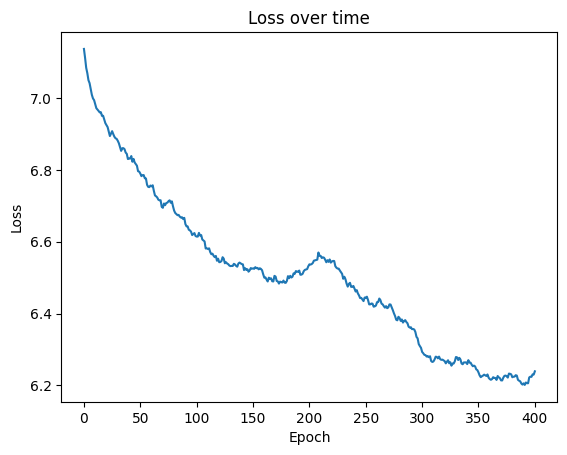

In [ ]:
# plot the losses with smoothing
window_size = 100
avg = np.convolve(losses, np.ones(window_size), mode='valid') / window_size
plt.plot(avg)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Loss over time')
plt.show()